# t-SNE Dimensionality Reduction Projections

t-Distributed Stochastic Neighbor Embedding (t-SNE) is a non-linear dimensionality reduction technique. It calculates probability distributions of coordinate pairs in high-dimensional space and maps them to low-dimensional distributions, preserving local structural clusters. This notebook generates synthetic 10-dimensional customer coordinates (3 distinct profiles), applies t-SNE, and visualizes the 2D clusters in Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Generate synthetic high-dimensional data (300 samples, 10 features, 3 clusters)
np.random.seed(170)
n_samples = 300
n_features = 10

# Cluster centers in 10D space
centers = [
    np.random.uniform(-4, 4, n_features),
    np.random.uniform(-4, 4, n_features),
    np.random.uniform(-4, 4, n_features)
]

X_list, y_list = [], []
for label, center in enumerate(centers):
    noise = np.random.normal(0, 0.45, (100, n_features))
    X_list.append(center + noise)
    y_list.append(np.full(100, label))

X = np.vstack(X_list)
y = np.concatenate(y_list)

df_tsne = pd.DataFrame(X, columns=[f"Attr_{i+1:02d}" for i in range(n_features)])
df_tsne['Cluster_Label'] = y
df_tsne.head(10)



,Attr_01,Attr_02,Attr_03,Attr_04,Attr_05,Attr_06,Attr_07,Attr_08,Attr_09,Attr_10,Cluster_Label
0,-3.452082,-2.341926,-1.572646,-0.354180,0.934648,0.194024,1.987971,-4.485352,3.527868,-0.630842,0
1,-3.588161,-2.202017,-2.765514,0.656361,0.475124,0.446979,0.909543,-3.354587,3.822705,-0.282466,0
2,-3.562190,-1.720887,-1.592220,0.335742,0.501155,0.334018,2.165959,-3.800118,2.713208,-0.486498,0
3,-4.356023,-1.996555,-2.785564,0.354311,1.379887,-0.681710,1.970468,-3.950098,4.148890,-0.173676,0
4,-3.901879,-1.309659,-1.768920,-0.723103,0.972312,0.163599,2.090782,-4.851634,3.246780,-0.327778,0
5,-3.304863,-2.779917,-1.342334,0.351675,0.343951,0.370743,1.328616,-4.348954,3.757650,-0.320262,0
6,-3.946276,-1.484614,-1.735507,-0.376885,0.538261,-0.227508,0.759819,-2.787325,3.297707,0.318159,0
7,-4.024572,-1.467506,-1.949513,-0.335948,1.050061,-0.021898,2.386589,-3.741506,4.070214,-0.638351,0
8,-4.066203,-2.040303,-1.517572,0.019151,0.142774,-0.318100,1.120614,-3.711400,3.733907,0.188006,0
9,-4.490880,-1.721777,-2.241526,0.474892,0.596525,-0.571588,2.382749,-4.002426,3.154284,-0.861462,0


## t-SNE Projection Pipeline

We fit a t-SNE manifold learning estimator to project our 10D features down to 2 principal visualization components, using a perplexity of 30.



In [2]:
# Train t-SNE
tsne = TSNE(n_components=2, perplexity=30.0, random_state=42)
X_embedded = tsne.fit_transform(X)

print(f"Original Feature Dimension: {X.shape}")
print(f"t-SNE Reduced Dimension:    {X_embedded.shape}")



Original Feature Dimension: (300, 10)
t-SNE Reduced Dimension:    (300, 2)


## 2D Manifold Cluster Scatter Plot

Using Matplotlib, we scatter the 2D projected coordinates, coloring markers according to their original cluster category profiles.



<cell>:23: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



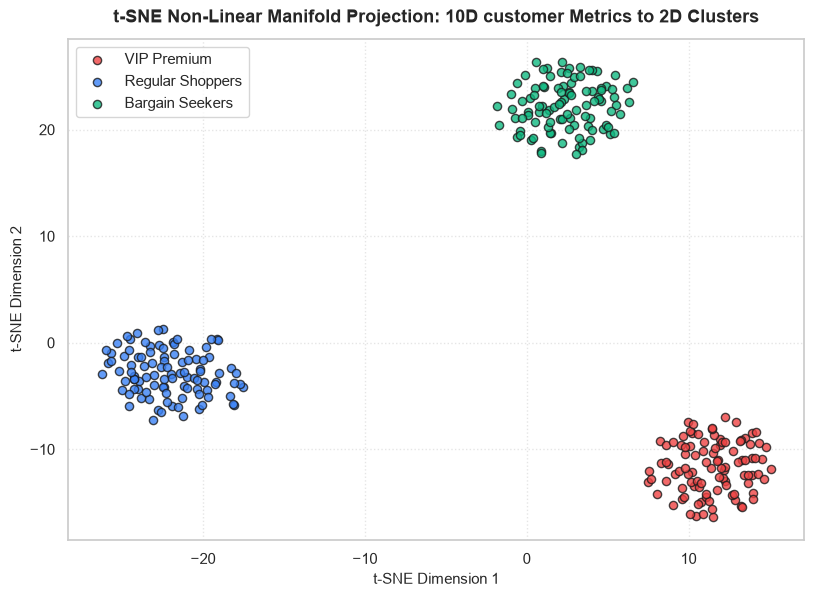

In [3]:
plt.figure(figsize=(9.5, 6.5))

colors = ['#EF4444', '#3B82F6', '#10B981']
labels = ['VIP Premium', 'Regular Shoppers', 'Bargain Seekers']

for i in range(3):
    indices = y == i
    plt.scatter(
        X_embedded[indices, 0], 
        X_embedded[indices, 1], 
        c=colors[i], 
        label=labels[i],
        edgecolors='k', 
        s=35, 
        alpha=0.8
    )

plt.title('t-SNE Non-Linear Manifold Projection: 10D customer Metrics to 2D Clusters', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('t-SNE Dimension 1', fontsize=11)
plt.ylabel('t-SNE Dimension 2', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
